# DEMO 2 — 進学率で相殺されたか？

## 分析前チェックリスト

- **問い**: 18 歳人口が減っているのに大学入学者数は減っていない。進学率上昇でどこまで相殺されたか？
- **予想**: 進学率は 2010 年頃に **50% 前後でプラトー**していると思っていた
- **反証条件**: もし 2010 → 2024 で **+2pt 以上**の上昇が続いていたら、プラトー予想は誤り
- **出典**: 文科省 学校基本調査 令和 6 年確定値


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 18 歳人口 (万人) / 大学入学者数 (万人) / 大学進学率 (%)
# 出典: 文科省 学校基本調査 令和 6 年確定値
data = [
    (1990, 201, 49.2, 24.6),   # 進学率は男女計、大学(学部)のみ
    (1995, 177, 56.8, 32.1),
    (2000, 151, 59.9, 39.7),
    (2005, 137, 60.3, 44.2),
    (2010, 122, 61.9, 50.9),
    (2015, 120, 61.8, 51.5),
    (2020, 118, 63.5, 54.4),
    (2024, 106, 63.3, 59.1),
]
df2 = pd.DataFrame(data, columns=["year", "jinkou_man", "nyugakusha_man", "shingaku_ritsu_pct"])
df2

,year,jinkou_man,nyugakusha_man,shingaku_ritsu_pct
0,1990,201,49.2,24.6
1,1995,177,56.8,32.1
2,2000,151,59.9,39.7
3,2005,137,60.3,44.2
4,2010,122,61.9,50.9
5,2015,120,61.8,51.5
6,2020,118,63.5,54.4
7,2024,106,63.3,59.1


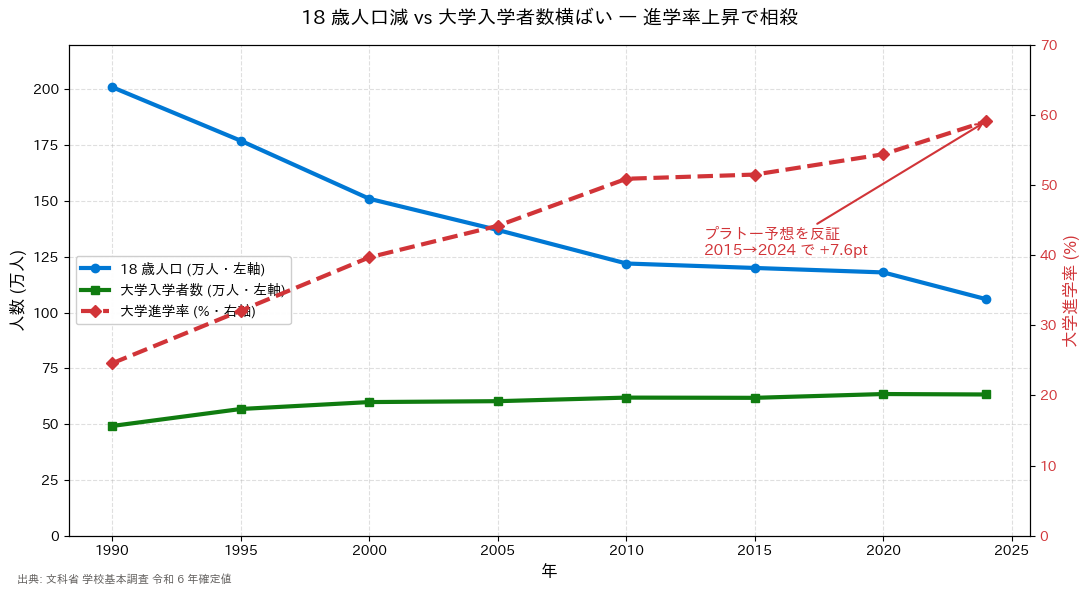

saved: ../assets/demo02_shingaku_ritsu.png


In [2]:
import os
OUT_DIR = "../assets"
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax1 = plt.subplots(figsize=(11, 6))

# 左軸: 18 歳人口 & 入学者数 (万人)
ax1.plot(df2["year"], df2["jinkou_man"], marker="o", linewidth=3,
         color="#0078D4", label="18 歳人口 (万人・左軸)")
ax1.plot(df2["year"], df2["nyugakusha_man"], marker="s", linewidth=3,
         color="#107C10", label="大学入学者数 (万人・左軸)")
ax1.set_xlabel("年", fontsize=12)
ax1.set_ylabel("人数 (万人)", fontsize=12)
ax1.set_ylim(0, 220)
ax1.grid(True, linestyle="--", alpha=0.4)

# 右軸: 進学率 (%)
ax2 = ax1.twinx()
ax2.plot(df2["year"], df2["shingaku_ritsu_pct"], marker="D", linewidth=3,
         color="#D13438", linestyle="--", label="大学進学率 (%・右軸)")
ax2.set_ylabel("大学進学率 (%)", fontsize=12, color="#D13438")
ax2.set_ylim(0, 70)
ax2.tick_params(axis="y", labelcolor="#D13438")

# 「プラトー予想」の反証を強調
ax2.annotate("プラトー予想を反証\n2015→2024 で +7.6pt",
             xy=(2024, 59.1), xytext=(2013, 40),
             fontsize=11, color="#D13438", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#D13438", lw=1.5))

# タイトル
ax1.set_title("18 歳人口減 vs 大学入学者数横ばい — 進学率上昇で相殺", fontsize=14, fontweight="bold", pad=15)

# 凡例統合
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=10, framealpha=0.95)

fig.text(0.02, 0.02, "出典: 文科省 学校基本調査 令和 6 年確定値", fontsize=8, color="#605E5C")

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/demo02_shingaku_ritsu.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved: {OUT_DIR}/demo02_shingaku_ritsu.png")

In [4]:
print("="*60)
print("DEMO 2 — 予想との差分レポート")
print("="*60)

print("\n【予想】 進学率は 2010 年頃に 50% 前後でプラトー")
print("        反証条件: 2015→2024 で +2pt 以上の上昇があれば予想は誤り\n")

r_2010 = df2[df2["year"]==2010]["shingaku_ritsu_pct"].values[0]
r_2015 = df2[df2["year"]==2015]["shingaku_ritsu_pct"].values[0]
r_2024 = df2[df2["year"]==2024]["shingaku_ritsu_pct"].values[0]
delta_15_24 = r_2024 - r_2015
delta_10_24 = r_2024 - r_2010

print(f"【実測】 2010 年 進学率: {r_2010}%")
print(f"        2015 年 進学率: {r_2015}%  (2010→2015: +{r_2015-r_2010:.1f}pt = 予想通り横ばい)")
print(f"        2024 年 進学率: {r_2024}%  (2015→2024: +{delta_15_24:.1f}pt = プラトー予想を反証)")
print(f"        2015→2024 差分: +{delta_15_24:.1f}pt (反証条件 +2pt の {delta_15_24/2:.1f} 倍)")

print("\n【反証条件の判定】")
print(f"  +{delta_15_24:.1f}pt > +2pt → ★予想は誤り。プラトーではなく再加速していた")

print("\n【入学者数の維持メカニズム】")
n_1990 = df2[df2["year"]==1990]["nyugakusha_man"].values[0]
n_2024 = df2[df2["year"]==2024]["nyugakusha_man"].values[0]
p_1990 = df2[df2["year"]==1990]["jinkou_man"].values[0]
p_2024 = df2[df2["year"]==2024]["jinkou_man"].values[0]
print(f"  18 歳人口: {p_1990} 万 → {p_2024} 万 ({(p_2024/p_1990-1)*100:+.1f}%)")
print(f"  入学者数:  {n_1990} 万 → {n_2024} 万 ({(n_2024/n_1990-1)*100:+.1f}%)")
print(f"  → 進学率 {24.6}% → {r_2024}% の上昇が母集団減少をほぼ完全に相殺")

DEMO 2 — 予想との差分レポート

【予想】 進学率は 2010 年頃に 50% 前後でプラトー
        反証条件: 2015→2024 で +2pt 以上の上昇があれば予想は誤り

【実測】 2010 年 進学率: 50.9%
        2015 年 進学率: 51.5%  (2010→2015: +0.6pt = 予想通り横ばい)
        2024 年 進学率: 59.1%  (2015→2024: +7.6pt = プラトー予想を反証)
        2015→2024 差分: +7.6pt (反証条件 +2pt の 3.8 倍)

【反証条件の判定】
  +7.6pt > +2pt → ★予想は誤り。プラトーではなく再加速していた

【入学者数の維持メカニズム】
  18 歳人口: 201 万 → 106 万 (-47.3%)
  入学者数:  49.2 万 → 63.3 万 (+28.7%)
  → 進学率 24.6% → 59.1% の上昇が母集団減少をほぼ完全に相殺
